# B3b Defense – 06 Forecast 2026 & Explainability

**Objective:** Rolling one-step-ahead forecast for ADEFNO (Jan–Dec 2026).
Export the raw ML market volume forecast as a SAC-ready CSV.
Generate per-month SHAP waterfall plots for explainability.

The market share assumption (what fraction of ADEFNO the company can capture) is a
management input configured directly in SAC — it is not computed here.

## Carry-Forward Assumption for Macro Features

External macro indicators (`IPB52300S`, `FDEFX` and their lag features) are **frozen at
their last known values** from the historical feature matrix. No macro trajectory is predicted.

ADEFNO-derived features (`adefno_lag_*`, `ADEFNO_diff_lag_*`, rolling windows) are updated
each step using the most recent predicted ADEFNO value, so the autoregressive structure
remains intact across the 12-month horizon.

The carry-forward approach is a recognised limitation of this forecast: if macro conditions
(defense production capacity, realized government expenditures) shift materially in 2026,
forecast accuracy will degrade. This should be disclosed as a model limitation in any
management presentation.

In [2]:
import os
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

C:\Users\gdenn\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
DATA_PROCESSED = '../data/processed/'
MODELS_DIR     = '../models/'

# Load model and historical feature matrix
model = joblib.load(MODELS_DIR + 'xgboost_defense_market.pkl')

df = pd.read_csv(DATA_PROCESSED + 'defense_feature_matrix.csv', parse_dates=['date'], index_col='date')
df = df.sort_index()

# Feature columns (all except target)
feature_cols = [col for col in df.columns if col != 'ADEFNO']

print(f'Model loaded. Feature matrix: {df.shape}')
print(f'Historical range: {df.index[0].date()} to {df.index[-1].date()}')

Model loaded. Feature matrix: (305, 32)
Historical range: 2000-08-01 to 2025-12-01


In [4]:
# Carry-forward setup
# Macro baseline: freeze last known row (IPB52300S, FDEFX and their lags stay fixed)
last_row_macro = df[feature_cols].iloc[-1].copy()

# Rolling buffer: last 7 historical ADEFNO values
# 7 values yield 6 consecutive diffs — enough to seed ADEFNO_diff_lag_1..6
hist_adefno = list(df['ADEFNO'].iloc[-7:].values)

# First-difference buffer derived from hist_adefno
# hist_diff[-1] = most recent diff (Dec 2025), hist_diff[-6] = oldest needed lag
hist_diff = [hist_adefno[i] - hist_adefno[i - 1] for i in range(1, len(hist_adefno))]

print(f'ADEFNO buffer   (last 7): {[round(v, 1) for v in hist_adefno]}')
print(f'ADEFNO_diff buffer (last 6): {[round(v, 1) for v in hist_diff]}')

ADEFNO buffer   (last 7): [np.int64(17229), np.int64(15263), np.int64(16013), np.int64(19906), np.int64(17282), np.int64(15435), np.int64(18774)]
ADEFNO_diff buffer (last 6): [np.int64(-1966), np.int64(750), np.int64(3893), np.int64(-2624), np.int64(-1847), np.int64(3339)]


In [5]:
# Rolling one-step-ahead forecast — Jan 2026 to Dec 2026
forecast_dates   = pd.date_range('2026-01', periods=12, freq='MS')
forecast_results = []

for forecast_date in forecast_dates:
    # Start from macro carry-forward baseline (IPB52300S, FDEFX, their lags)
    row = last_row_macro.copy()

    # --- Calendar features ---
    row['month']   = forecast_date.month
    row['quarter'] = forecast_date.quarter
    row['year']    = forecast_date.year
    row['is_q4']   = int(forecast_date.quarter == 4)

    # --- Autoregressive lags on absolute ADEFNO level ---
    row['adefno_lag_1'] = hist_adefno[-1]
    row['adefno_lag_2'] = hist_adefno[-2]
    row['adefno_lag_3'] = hist_adefno[-3]

    # --- Rolling window features (shift=1 means prior-month values only) ---
    row['adefno_rolling_3m_mean'] = np.mean(hist_adefno[-3:])
    row['adefno_rolling_3m_std']  = np.std(hist_adefno[-3:], ddof=1)
    row['adefno_rolling_6m_mean'] = np.mean(hist_adefno[-6:])
    row['adefno_rolling_6m_std']  = np.std(hist_adefno[-6:], ddof=1)

    # --- ADEFNO_diff: carry forward last known diff (conservative baseline) ---
    row['ADEFNO_diff'] = hist_diff[-1]

    # --- ADEFNO_diff lags: lag_1 = most recent diff, lag_6 = oldest ---
    for lag in range(1, 7):
        row[f'ADEFNO_diff_lag_{lag}'] = hist_diff[-lag]

    # --- Predict ---
    X_row       = pd.DataFrame([row[feature_cols]])
    adefno_pred = float(model.predict(X_row)[0])

    forecast_results.append({
        'date':                 forecast_date,
        'adefno_forecast_musd': adefno_pred
    })

    # --- Update buffers for next step ---
    new_diff = adefno_pred - hist_adefno[-1]
    hist_adefno.append(adefno_pred)
    hist_diff.append(new_diff)

print('Rolling forecast complete.')

Rolling forecast complete.


In [6]:
# Build results DataFrame
forecast_df = pd.DataFrame(forecast_results)

print(forecast_df.to_string(index=False))

      date  adefno_forecast_musd
2026-01-01          15092.243164
2026-02-01          11482.616211
2026-03-01          10117.871094
2026-04-01          10020.948242
2026-05-01          11100.929688
2026-06-01          12600.931641
2026-07-01          13713.129883
2026-08-01          14258.030273
2026-09-01          13997.829102
2026-10-01          13644.155273
2026-11-01          13440.603516
2026-12-01          13520.386719


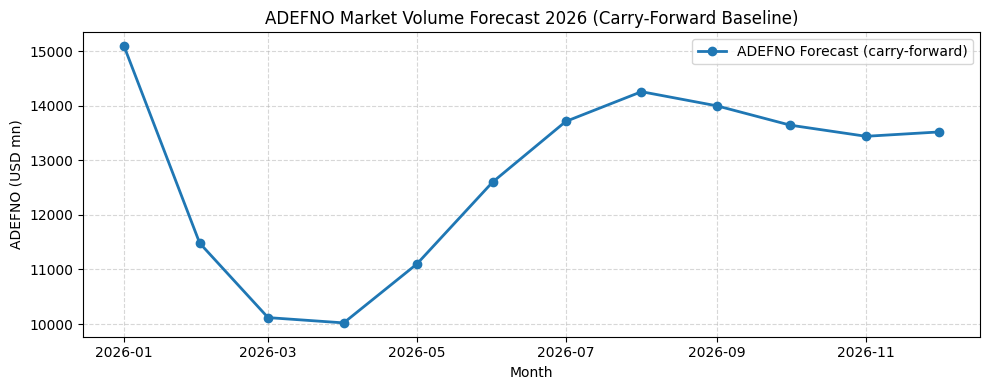

Saved: ../models/model_output/defense_forecast_2026.png


In [7]:
# Plot ADEFNO forecast
MODEL_OUTPUT = MODELS_DIR + 'model_output/'
os.makedirs(MODEL_OUTPUT, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    forecast_df['date'],
    forecast_df['adefno_forecast_musd'],
    marker='o',
    linewidth=2,
    label='ADEFNO Forecast (carry-forward)'
)
ax.set_title('ADEFNO Market Volume Forecast 2026 (Carry-Forward Baseline)')
ax.set_xlabel('Month')
ax.set_ylabel('ADEFNO (USD mn)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(MODEL_OUTPUT + 'defense_forecast_2026.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'Saved: {MODEL_OUTPUT}defense_forecast_2026.png')

In [8]:
# SAC export — raw ADEFNO market volume (USD)
# ADEFNO is in USD millions → multiply by 1_000_000 for SAC (full USD)
# Market share is applied as a parameter in SAC, not here
sac_rows = []

for _, row in forecast_df.iterrows():
    sac_rows.append({
        'Date':          int(row['date'].strftime('%Y%m')),
        'Country':       'US',
        'Segment':       'Defense',
        'Net_Value_USD': round(row['adefno_forecast_musd'] * 1_000_000, 2)
    })

sac_df = pd.DataFrame(sac_rows)
sac_path = DATA_PROCESSED + 'defense_forecast_2026_sac.csv'
sac_df.to_csv(sac_path, index=False)

print(f'SAC export saved to: {sac_path}')
print(f'Shape: {sac_df.shape}')
print(sac_df.to_string(index=False))

SAC export saved to: ../data/processed/defense_forecast_2026_sac.csv
Shape: (12, 4)
  Date Country Segment  Net_Value_USD
202601      US Defense   1.509224e+10
202602      US Defense   1.148262e+10
202603      US Defense   1.011787e+10
202604      US Defense   1.002095e+10
202605      US Defense   1.110093e+10
202606      US Defense   1.260093e+10
202607      US Defense   1.371313e+10
202608      US Defense   1.425803e+10
202609      US Defense   1.399783e+10
202610      US Defense   1.364416e+10
202611      US Defense   1.344060e+10
202612      US Defense   1.352039e+10


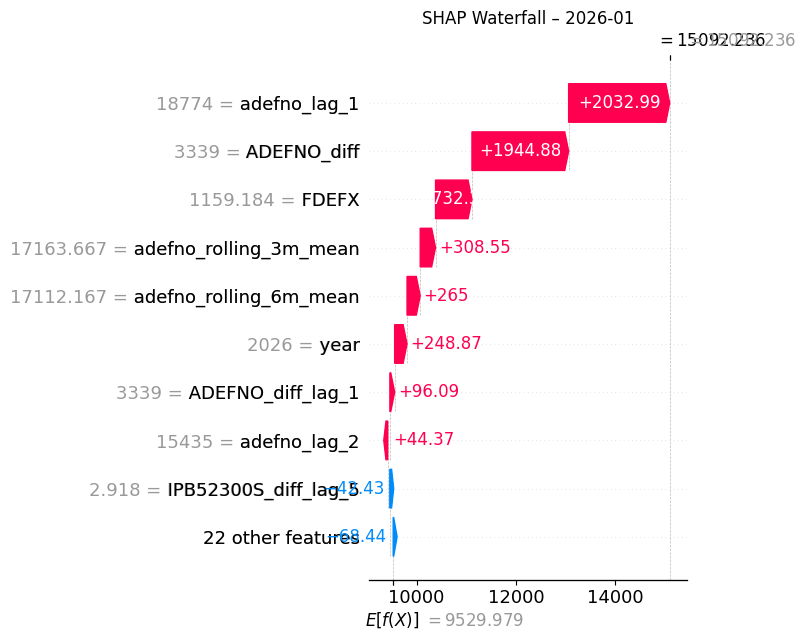

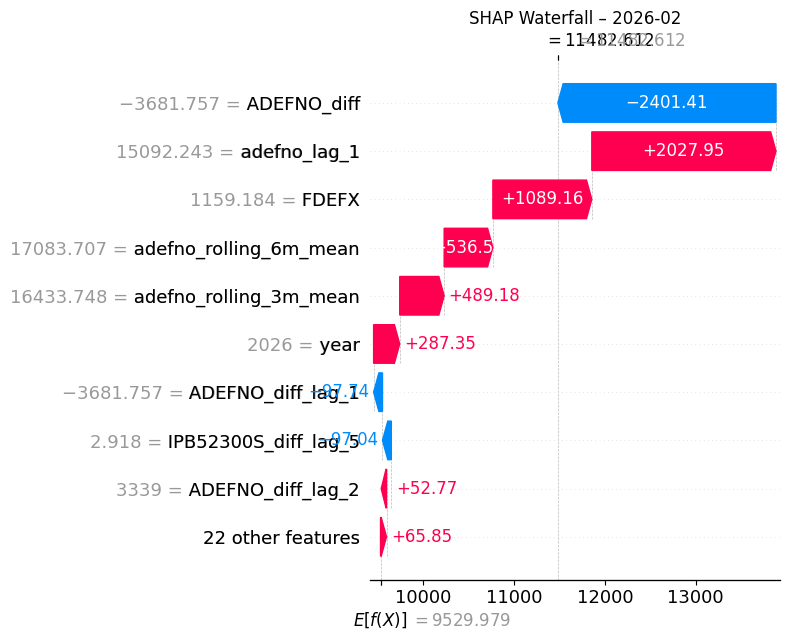

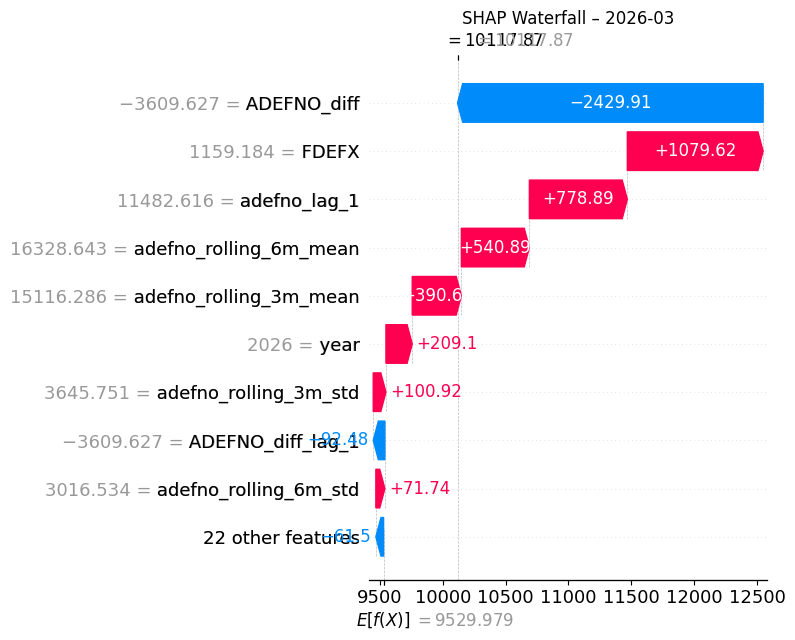

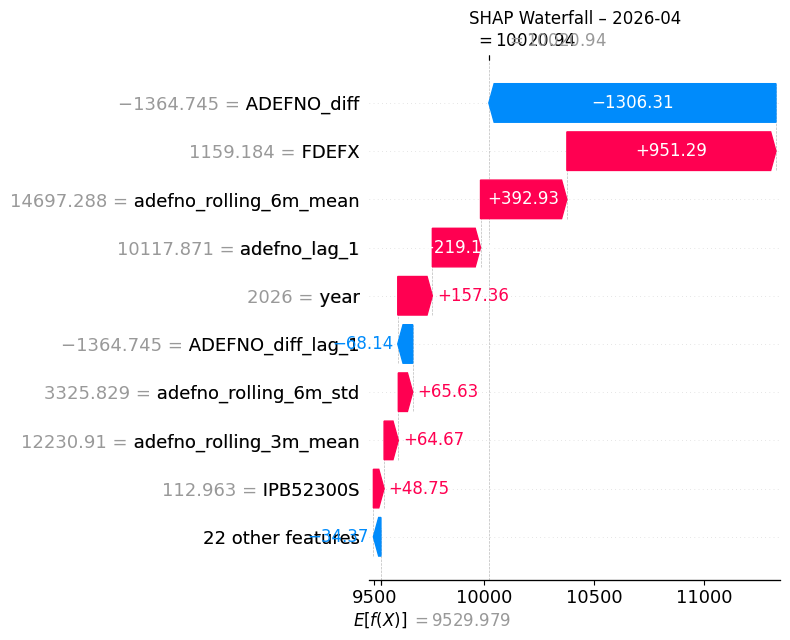

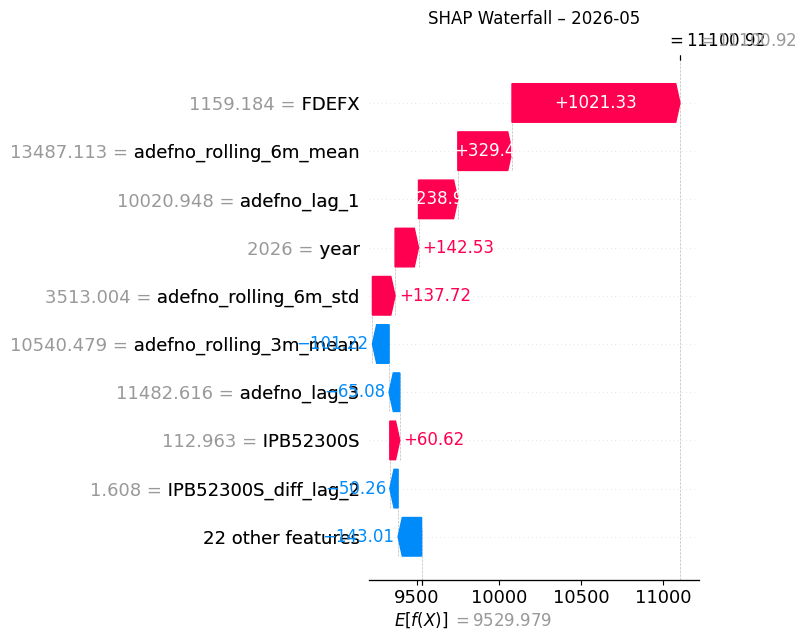

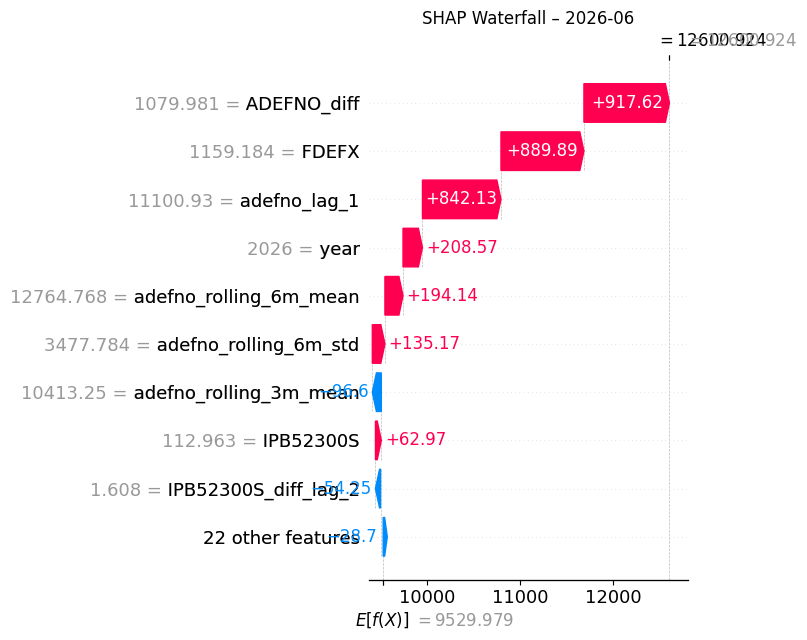

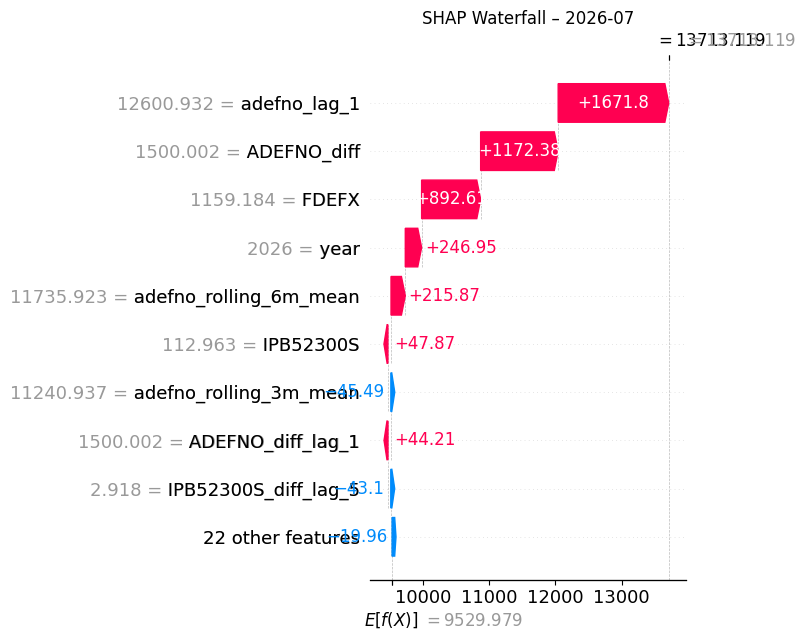

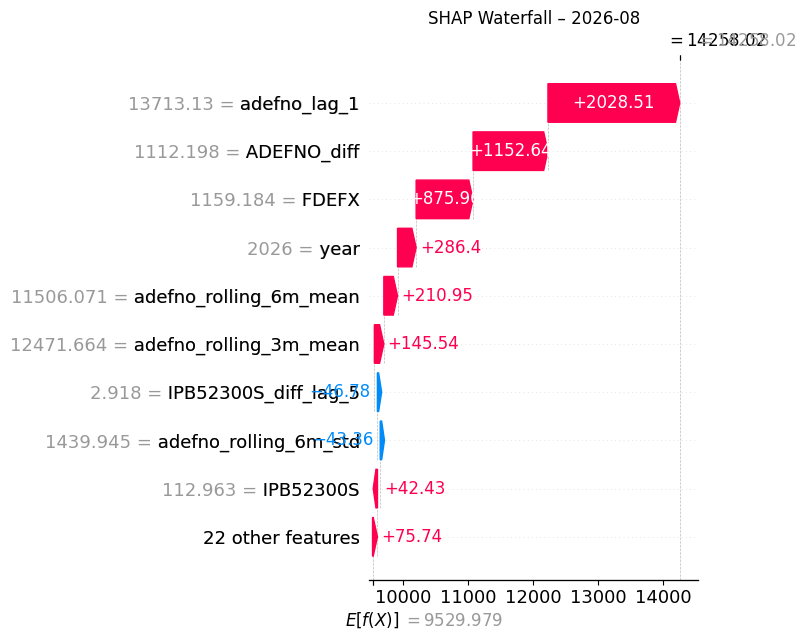

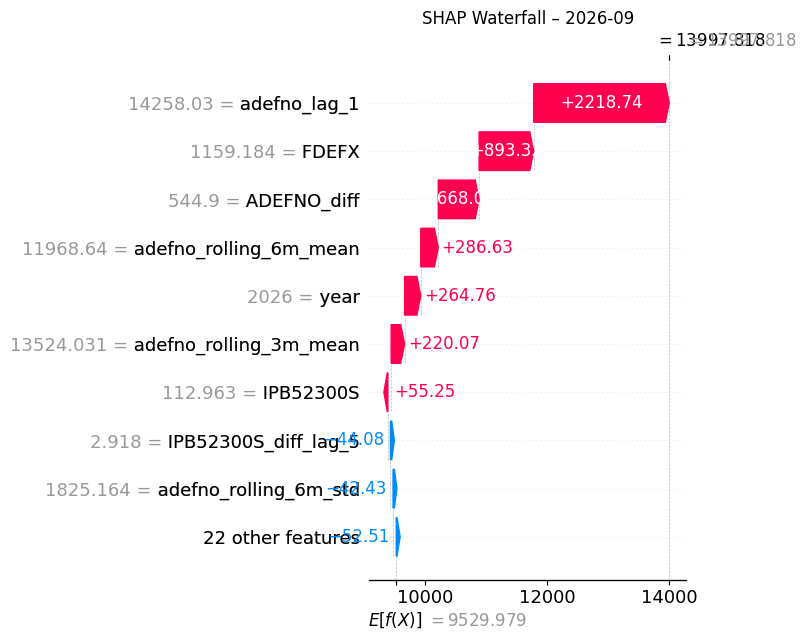

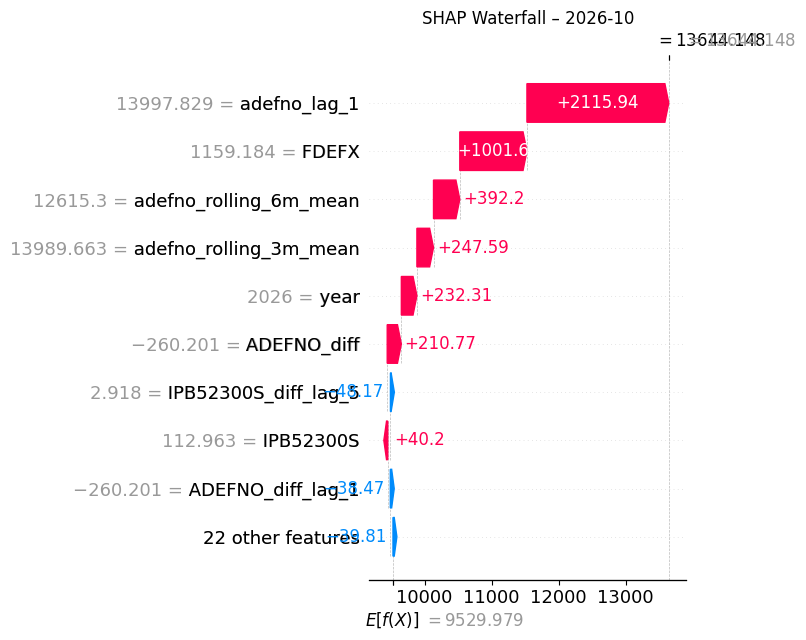

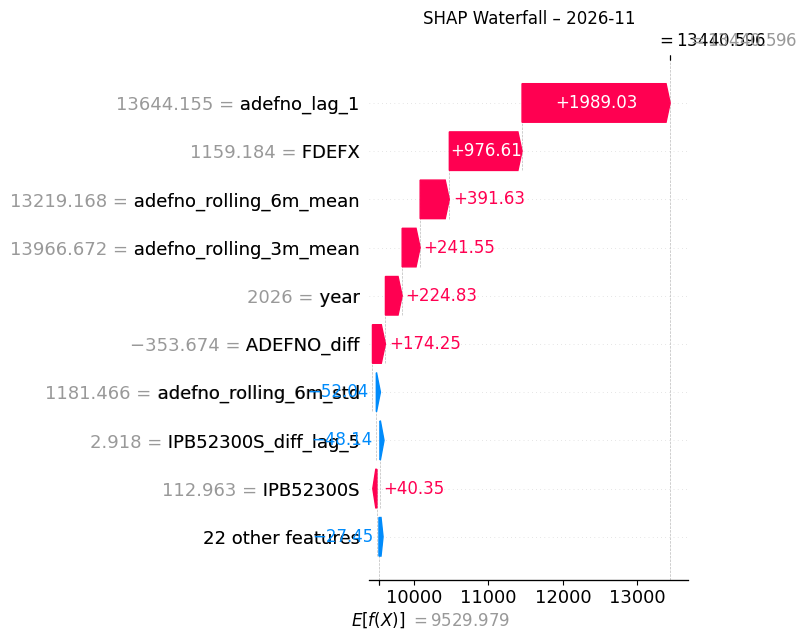

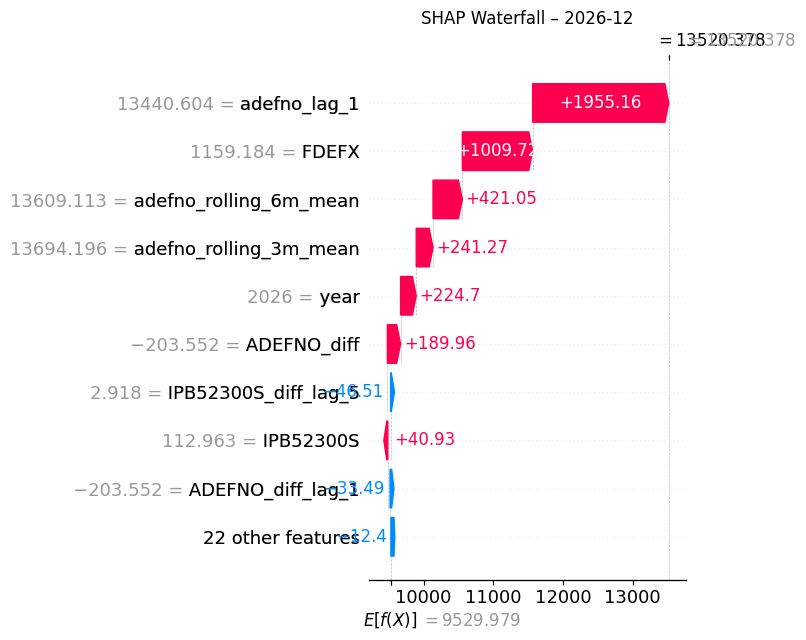

Waterfall plots saved to ../models/model_output/


In [9]:
# SHAP waterfall plots for each forecast month
# Rebuild feature rows using the same rolling logic as the forecast loop above
explainer = shap.TreeExplainer(model)

# Re-initialise buffers from historical data (independent of the forecast loop above)
hist_adefno_shap = list(df['ADEFNO'].iloc[-7:].values)
hist_diff_shap   = [hist_adefno_shap[i] - hist_adefno_shap[i - 1]
                    for i in range(1, len(hist_adefno_shap))]

for forecast_date in forecast_dates:
    row = last_row_macro.copy()

    row['month']   = forecast_date.month
    row['quarter'] = forecast_date.quarter
    row['year']    = forecast_date.year
    row['is_q4']   = int(forecast_date.quarter == 4)

    row['adefno_lag_1'] = hist_adefno_shap[-1]
    row['adefno_lag_2'] = hist_adefno_shap[-2]
    row['adefno_lag_3'] = hist_adefno_shap[-3]

    row['adefno_rolling_3m_mean'] = np.mean(hist_adefno_shap[-3:])
    row['adefno_rolling_3m_std']  = np.std(hist_adefno_shap[-3:], ddof=1)
    row['adefno_rolling_6m_mean'] = np.mean(hist_adefno_shap[-6:])
    row['adefno_rolling_6m_std']  = np.std(hist_adefno_shap[-6:], ddof=1)

    row['ADEFNO_diff'] = hist_diff_shap[-1]
    for lag in range(1, 7):
        row[f'ADEFNO_diff_lag_{lag}'] = hist_diff_shap[-lag]

    X_row = pd.DataFrame([row[feature_cols]])
    sv    = explainer.shap_values(X_row)

    explanation = shap.Explanation(
        values        = sv[0],
        base_values   = explainer.expected_value,
        data          = X_row.values[0],
        feature_names = feature_cols
    )

    shap.plots.waterfall(explanation, show=False)
    plt.title(f'SHAP Waterfall – {forecast_date.strftime("%Y-%m")}')
    plt.tight_layout()
    date_str = forecast_date.strftime('%Y_%m')
    plt.savefig(MODEL_OUTPUT + f'shap_waterfall_{date_str}.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    # Update buffers
    pred_val = float(model.predict(X_row)[0])
    new_diff = pred_val - hist_adefno_shap[-1]
    hist_adefno_shap.append(pred_val)
    hist_diff_shap.append(new_diff)

print(f'Waterfall plots saved to {MODEL_OUTPUT}')

## Forecast Results – Assessment

### ADEFNO Market Volume Forecast 2026

| Month | ADEFNO (USD mn) |
|-------|----------------|
| Jan 2026 | 15,092 |
| Feb 2026 | 11,483 |
| Mar 2026 | 10,118 |
| Apr 2026 | 10,021 |
| May 2026 | 11,101 |
| Jun 2026 | 12,601 |
| Jul 2026 | 13,713 |
| Aug 2026 | 14,258 |
| Sep 2026 | 13,998 |
| Oct 2026 | 13,644 |
| Nov 2026 | 13,441 |
| Dec 2026 | 13,520 |
| **Full year** | **~152,990** |

The SAC export contains the raw market volume in full USD (`Net_Value_USD = ADEFNO × 1,000,000`).
The market share assumption is applied as a parameter directly in SAC — not pre-computed here.

---

### Forecast Shape: Nike-Swoosh Pattern

The plot shows a clear U-shaped trajectory: a high January start, a trough in April,
recovery through August, and stabilization through December. This has a concrete cause:

**December 2025 was historically high at 18,774 USD mn**, with ADEFNO_diff = +3,339 —
a strong positive swing. This drives the January forecast to 15,092. From February onward,
the model gradually gives back this spike: as the model's own (lower) January prediction
feeds in as `adefno_lag_1` for February, a sharp correction follows.

**This pattern is a model artifact of the autoregressive structure — not a genuine market
signal for a Q1 demand collapse.** The model cannot distinguish between a one-off large
contract and a structural trend change. From May onward, the forecast stabilizes as the
rolling windows absorb and average out the historical outlier, and the model converges
toward a quasi-equilibrium.

---

### SHAP Waterfall — Three Key Moments

**January 2026 (forecast: 15,092 USD mn)**
The two dominant drivers are `adefno_lag_1` = 18,774 (+2,033) and `ADEFNO_diff` = 3,339
(+1,945). The model directly extrapolates the December momentum. FDEFX contributes +732
but is clearly secondary at this stage.

**June 2026 (forecast: 12,601 USD mn)**
The picture has shifted: `adefno_lag_1` is now 11,101 (the model's own May prediction)
and contributes only +842. FDEFX moves to +890 and for the first time exceeds the AR lag —
because without a historical spike to process, the frozen macro feature becomes proportionally
more dominant. This transition is methodologically expected and correct.

**December 2026 (forecast: 13,520 USD mn)**
The model has fully stabilized. `adefno_lag_1` = 13,441 (+1,955), FDEFX = 1,159 (+1,009).
`ADEFNO_diff` has turned slightly negative (−203) but still contributes +190; meanwhile
`ADEFNO_diff_lag_1` = −203 already pulls slightly against (−149). The system is
near-equilibrium — a steady state rather than a genuine month-specific forecast.

---

### Overall Assessment

**What the model does well:**
- The annual ADEFNO sum of ~153,000 USD mn is a plausible order of magnitude for the
  US defense procurement market — structurally consistent with historical 2020s levels.
- FDEFX gains weight over the year as autoregressive momentum fades, which is
  methodologically correct: when short-term momentum dissipates, the external macro
  driver stabilizes the prediction.
- The `year` feature contributes a stable +225 to +249 USD mn per month throughout,
  correctly carrying the defense sector's structural upward trend into 2026.

**Methodological limitations — to be disclosed in the thesis:**

1. **January spike is a data artifact, not a signal.** The elevated December 2025 value
   is a random high point in the data, not a structural trend break. A human analyst
   would not forecast 15,092 for January — but the model has no mechanism to distinguish
   between a one-off contract and a genuine trend change.

2. **H2 stabilization is convergence, not forecasting.** From approximately June onward,
   the model gravitates toward its own expectation anchor. Monthly values from
   September to December cluster tightly (~13,440–13,520 USD mn). This is a known
   property of rolling one-step-ahead forecasts over long horizons: autoregressive
   features eventually follow their own outputs, reducing effective forecast variation.

3. **ADEFNO_diff is frozen for the full horizon.** Carrying forward the December diff
   (+3,339) into January is appropriate. For subsequent months the diff is recomputed
   from consecutive predictions, which is correct. However, this means the carry-forward
   baseline assumption compounds over the forecast horizon — a limitation that should be
   stated when presenting the results to management.

**Conclusion for the thesis:** The forecast delivers a credible range for the addressable
market volume (~10,000–15,000 USD mn per month). It is suitable as a data-backed benchmark
for management discussions. Month-level precision should not be claimed — particularly Q1 2026
is strongly influenced by the historical December 2025 outlier. The market share applied
to this volume is a separate management decision made in SAC.